<a href="https://colab.research.google.com/github/banikinkar/Assignments_Of_AI/blob/main/Text_Embeddings_Demystified_From_Representation_to_Clusters_(2)_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Text Embeddings – Introduction**

* Text embeddings convert text (words, sentences, or documents) into **numerical vectors** so that machines can understand and process language.
* They capture the **semantic meaning** of text, where similar words or sentences have **similar vector representations**.
* Unlike traditional methods like **Bag-of-Words** or **TF-IDF**, embeddings preserve **context and relationships between words**.
* Generated using models such as **Word2Vec, GloVe, FastText, and BERT**.
* Widely used in **semantic search, recommendation systems, clustering, and Retrieval-Augmented Generation (RAG)**.


In [ ]:
!pip install gensim   # Install Gensim library for Word2Vec and other NLP models (run in Colab or Jupyter)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 26.9 MB/s eta 0:00:00


**Importing Libraries**

In [ ]:
import numpy as np                           # NumPy for numerical computations, arrays, matrices, and math operations
import matplotlib.pyplot as plt              # Matplotlib for creating plots, charts, and visualizations

from sklearn.feature_extraction.text import (
    CountVectorizer,                         # Converts text into a Bag-of-Words matrix (word counts per sentence)
    TfidfVectorizer                          # Converts text into a TF–IDF weighted matrix (importance of words per sentence)
)

from sklearn.cluster import KMeans           # KMeans clustering algorithm for grouping embeddings into clusters
from sklearn.decomposition import (
    TruncatedSVD,                            # Dimensionality reduction method to reduce high-dimensional text vectors
    PCA                                      # Principal Component Analysis for reducing embeddings to lower dimensions (e.g., 2D for plotting)
)

from sklearn.metrics.pairwise import (
    euclidean_distances,                     # Computes Euclidean distances between all pairs of vectors (similarity/dissimilarity measure)
    cosine_similarity                        # Computes cosine similarity between vectors (angle-based similarity measure)
)

from sentence_transformers import SentenceTransformer   # Pre-trained BERT-like model for generating dense sentence embeddings capturing semantic meaning

from gensim.models import Word2Vec          # Word2Vec model for generating dense word embeddings capturing semantic similarity
from gensim.utils import simple_preprocess   # Preprocessing utility: tokenizes text, lowercases, removes punctuation and numbers


**Sentences for Embedding and Clustering Analysis**

In [ ]:
sentences = [
    "Delhi is the capital of India.",
    "Tokyo is a major city in Japan.",
    "Paris is known as the city of lights.",
    "New York is one of the busiest cities in the world.",
    "London is famous for its historical landmarks.",
    "Sydney is a coastal city known for the Opera House.",
    "LLMs are used for text processing.",
    "Transformers help machines understand language.",
    "NLP models learn linguistic patterns.",
    "Tokenization converts text into numerical units.",
    "Language models generate human-like responses.",
    "Text classification assigns labels to sentences.",
    "CNNs are popular for image classification.",
    "Vision Transformers perform well on image tasks.",
    "Object detection identifies items in pictures.",
    "Image segmentation divides an image into meaningful regions.",
    "Face recognition systems detect and identify faces.",
    "Optical character recognition extracts text from images."
]

# **COUNT-VECTORIZER**

**CountVectorizer Embeddings**


1. **Text to Numbers:** Transforms raw text into a numerical format so machine learning algorithms can process it effectively.

2. **Vocabulary Creation:** Scans all sentences in the dataset to build a comprehensive list of all unique words.

3. **Vector Representation:** Represents each sentence as a fixed-length vector, where each dimension corresponds to a word from the vocabulary.

4. **Word Counts:** Each element of the vector stores the frequency of the corresponding word in the sentence, capturing the occurrence information.

5. **Sparse to Dense Matrix:** Outputs a matrix where rows represent sentences and columns represent vocabulary words; initially sparse, it can be converted to a dense array for easier visualization and computation.



In [ ]:
cv = CountVectorizer()
# CountVectorizer creates a Bag-of-Words (BoW) model.
# What it does:
# 1. Scans all sentences.
# 2. Builds a vocabulary of every unique word.
# 3. For each sentence, it creates a row vector.
# 4. Each column represents a word from the vocabulary.
# 5. Each value is how many times that word appears in that sentence.

emb_cv = cv.fit_transform(sentences).toarray()
# fit_transform():
#   • fit()  → learns the vocabulary from the entire dataset.
#   • transform() → converts each sentence into a numerical vector
#                    where every position = count of a vocabulary word.
# toarray() converts the sparse matrix (default format) into a normal dense NumPy array
# so it can be printed and used easily.

print("\n CountVectorizer Embedding Matrix:\n",
      np.round(emb_cv, 4))
# np.round(..., 4) → rounds numbers to 4 decimal places for cleaner display.
# The printed output is the full BoW matrix where:
#   • Rows = sentences.
#   • Columns = words in the vocabulary.
#   • Values = counts of each word in each sentence.



 CountVectorizer Embedding Matrix:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [1 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


**Compute Distances and Similarities**



1. **Euclidean Distance:** Measures how far apart sentence vectors are in the multi-dimensional word-count space.

2. **Distance Matrix:** Creates a square matrix where each entry shows the distance between two sentences.

3. **Sum of Squared Distances (SSD):** Aggregates all pairwise distances into a single number, representing overall spread of sentences.

4. **Cosine Similarity:** Measures similarity between sentences based on the angle between their vectors, focusing on word overlap rather than magnitude.

5. **Similarity Matrix:** Produces a matrix where higher values indicate sentences share more words and are more semantically similar.


In [ ]:
# Calculate Euclidean distance between all sentence vectors.
# This creates a matrix where each entry (i, j) shows how far
# sentence i is from sentence j based on their word-count patterns.
D_cv = euclidean_distances(emb_cv)
print("\n Euclidean Distance Matrix (CountVectorizer):\n", np.round(D_cv, 4))


# Compute the Sum of Squared Distances (SSD).
# This gives one overall number representing how spread out
# all the sentence vectors are in the CountVectorizer space.
SSD_cv = np.sum(D_cv**2)
print("\n Sum of Squared Distances (SSD CountVectorizer):", SSD_cv)


# Compute cosine similarity between every pair of sentence vectors.
# This tells how similar two sentences are by comparing the angle
# between their vectors rather than their absolute values.
# Higher value → sentences share more common words.
cos_cv = cosine_similarity(emb_cv)
print("\n Cosine Similarity Matrix (CountVectorizer):\n", np.round(cos_cv, 4))



 Euclidean Distance Matrix (CountVectorizer):
 [[0.     3.1623 2.8284 3.3166 3.3166 3.3166 3.4641 3.3166 3.3166 3.4641
  3.4641 3.4641 3.4641 3.6056 3.4641 4.     3.6056 3.6056]
 [3.1623 0.     3.1623 3.873  3.3166 3.3166 3.4641 3.3166 3.3166 3.4641
  3.4641 3.4641 3.4641 3.6056 3.1623 4.     3.6056 3.6056]
 [2.8284 3.1623 0.     3.6056 3.6056 3.     3.7417 3.6056 3.6056 3.7417
  3.7417 3.7417 3.7417 3.873  3.7417 4.2426 3.873  3.873 ]
 [3.3166 3.873  3.6056 0.     4.2426 4.     4.3589 4.2426 4.2426 4.3589
  4.3589 4.3589 4.3589 4.4721 4.1231 4.7958 4.4721 4.4721]
 [3.3166 3.3166 3.6056 4.2426 0.     3.4641 3.3166 3.4641 3.4641 3.6056
  3.6056 3.6056 3.3166 3.7417 3.6056 4.1231 3.7417 3.7417]
 [3.3166 3.3166 3.     4.     3.4641 0.     3.6056 3.7417 3.7417 3.873
  3.873  3.873  3.6056 4.     3.873  4.3589 4.     4.    ]
 [3.4641 3.4641 3.7417 4.3589 3.3166 3.6056 0.     3.3166 3.3166 3.1623
  3.4641 3.1623 2.8284 3.6056 3.4641 4.     3.6056 3.3166]
 [3.3166 3.3166 3.6056 4.2426 3.4641

**KMeans Clustering**


1. **Clustering Goal:** Groups sentences into clusters based on similarity in word count patterns.

2. **Number of Clusters:** Sentences are divided into a set number of groups according to their similarities.

3. **Multiple Initializations:** The algorithm tests multiple starting points to improve clustering quality.

4. **Reproducibility:** A fixed random seed ensures that results are consistent across runs.

5. **Cluster Labels:** Each sentence is assigned a label indicating the group it belongs to, representing similarity in the word-count space.


In [ ]:
# Create a KMeans clustering model that will form 3 clusters.
# n_init=10 means KMeans will try 10 different initializations
# and choose the best one based on the lowest total within-cluster distance.
# random_state=42 ensures the result is reproducible every time you run it.
km_cv = KMeans(n_clusters=3, n_init=10, random_state=42)

# Fit the model on the CountVectorizer embeddings and assign each
# sentence to one of the 3 clusters. The output is a list where each
# element indicates the cluster number for that sentence.
labels_cv = km_cv.fit_predict(emb_cv)

# Print the cluster label for each sentence, showing how KMeans grouped them.
print("\n Cluster Labels (CountVectorizer):", labels_cv)



 Cluster Labels (CountVectorizer): [1 1 1 1 0 1 0 0 0 0 0 0 0 2 0 2 0 0]


**PCA for 2D Visualization**


1. **Dimensionality Reduction:** Reduces high-dimensional word-count vectors to just two dimensions.

2. **Principal Components:** Identifies the directions that capture the most variance in the data.

3. **Visualization:** Makes it possible to plot the sentences and clusters on a 2D plane.

4. **Variance Preservation:** Retains the main structure and relationships between sentences.

5. **Interpretability:** Helps visually interpret how sentences are grouped based on their word patterns.


In [ ]:
# Apply PCA to reduce the CountVectorizer embeddings to 2 dimensions.
# PCA finds the two most important directions (principal components)
# that capture the maximum variance in the original high-dimensional data.
# This reduced 2D representation is mainly used for plotting the clusters visually.
pts_cv = PCA(n_components=2).fit_transform(emb_cv)


**Plot Clusters**

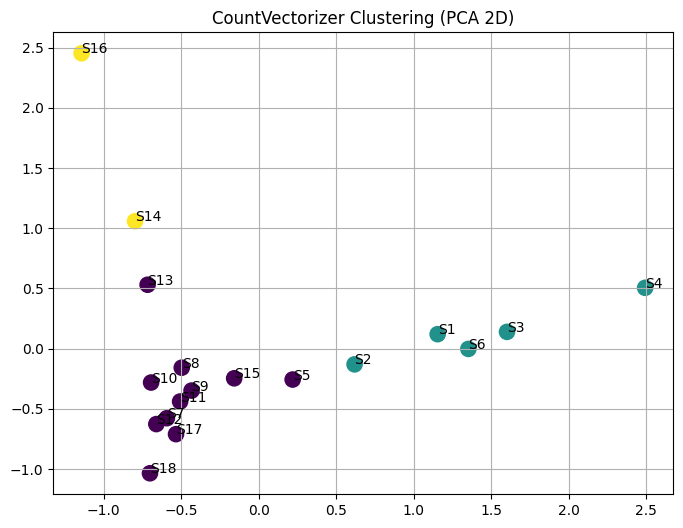

In [ ]:
# Create a plotting canvas with a fixed size so the visualization is clear.
plt.figure(figsize=(8,6))

# Plot each sentence as a point in 2D space using the PCA-reduced coordinates.
# 'c=labels_cv' colors each point based on its assigned cluster.
# 's=120' sets the size of the points.
# 'cmap="viridis"' chooses the color palette for the clusters.
plt.scatter(pts_cv[:,0], pts_cv[:,1], c=labels_cv, s=120, cmap='viridis')

# Add labels "S1", "S2", ... near each point so we can identify which sentence it represents.
for i in range(len(sentences)):
    plt.annotate(f"S{i+1}", (pts_cv[i,0], pts_cv[i,1]))

# Set the title of the plot to describe what is being visualized.
plt.title("CountVectorizer Clustering (PCA 2D)")

# Add grid lines to make distances and positions easier to see.
plt.grid(True)

# Display the final scatter plot.
plt.show()


# TF-IDF

**TF–IDF Embeddings**


1. **Numerical Conversion:** Transforms text into numbers so algorithms can work with it.

2. **Importance Weighting:** Captures how significant a word is in a sentence compared to the entire dataset.

3. **Vocabulary Structure:** Each unique word in the dataset forms a feature (column) in the vector.

4. **Sentence Representation:** Each sentence becomes a vector where values indicate weighted contribution of words.

5. **Meaningful Differentiation:** Rare but important words get higher influence, while common words get lower weight.


In [ ]:
# Initialize TF–IDF vectorizer
tfidf = TfidfVectorizer()  # Converts text into TF–IDF weighted numerical vectors

# Fit the vectorizer on sentences and transform into a matrix
emb_tfidf = tfidf.fit_transform(sentences).toarray()  # Each row = sentence, each column = word's TF–IDF weight

# Print the resulting embedding matrix
print("\n### TF–IDF Embedding Matrix:\n", np.round(emb_tfidf, 4))



### TF–IDF Embedding Matrix:
 [[0.     0.     0.     ... 0.     0.     0.    ]
 [0.     0.     0.     ... 0.     0.     0.    ]
 [0.     0.     0.     ... 0.     0.     0.    ]
 ...
 [0.3483 0.     0.     ... 0.     0.     0.    ]
 [0.     0.3844 0.     ... 0.     0.     0.    ]
 [0.     0.     0.     ... 0.     0.     0.    ]]


**Compute Distances and Similarities**


1. **Euclidean Distance:** Measures how far apart sentences are in the TF–IDF space. Smaller values indicate sentences are more similar in word usage.

2. **Distance Matrix:** A table where each entry shows the distance between a pair of sentences.

3. **Sum of Squared Distances (SSD):** A single number summarizing overall spread of all sentences in the TF–IDF space. Higher values indicate more diversity.

4. **Cosine Similarity:** Measures the angle between sentence vectors. Higher values mean sentences share more important words regardless of length.

5. **Similarity Matrix:** A table showing pairwise similarity scores, helping to identify which sentences are semantically closer.


In [ ]:
# Compute pairwise Euclidean distances between sentences
D_tfidf = euclidean_distances(emb_tfidf)  # Measures straight-line distance in high-dimensional TF–IDF space
print("\n Euclidean Distance Matrix (TF–IDF):\n", np.round(D_tfidf, 4))

# Sum of Squared Distances (SSD) gives an overall measure of spread/closeness
SSD_tfidf = np.sum(D_tfidf**2)
print("\n Sum of Squared Distances (SSD TF–IDF):", SSD_tfidf)

# Compute cosine similarity between sentences
cos_tfidf = cosine_similarity(emb_tfidf)  # Measures angle between vectors; higher = more similar
print("\n Cosine Similarity Matrix (TF–IDF):\n", np.round(cos_tfidf, 4))



 Euclidean Distance Matrix (TF–IDF):
 [[0.     1.3544 1.1889 1.1773 1.3614 1.2951 1.4142 1.4142 1.4142 1.4142
  1.4142 1.4142 1.4142 1.4142 1.4142 1.4142 1.4142 1.4142]
 [1.3544 0.     1.272  1.3045 1.362  1.2822 1.4142 1.4142 1.4142 1.4142
  1.4142 1.4142 1.4142 1.4142 1.3255 1.4142 1.4142 1.4142]
 [1.1889 1.272  0.     1.2096 1.3681 1.1314 1.4142 1.4142 1.4142 1.4142
  1.4142 1.4142 1.4142 1.4142 1.4142 1.4142 1.4142 1.4142]
 [1.1773 1.3045 1.2096 0.     1.3784 1.2855 1.4142 1.4142 1.4142 1.4142
  1.4142 1.4142 1.4142 1.4142 1.3536 1.4142 1.4142 1.4142]
 [1.3614 1.362  1.3681 1.3784 0.     1.3106 1.3439 1.4142 1.4142 1.4142
  1.4142 1.4142 1.3429 1.4142 1.4142 1.4142 1.4142 1.4142]
 [1.2951 1.2822 1.1314 1.2855 1.3106 0.     1.3488 1.4142 1.4142 1.4142
  1.4142 1.4142 1.3479 1.4142 1.4142 1.4142 1.4142 1.4142]
 [1.4142 1.4142 1.4142 1.4142 1.3439 1.3488 0.     1.4142 1.4142 1.3398
  1.4142 1.3398 1.2076 1.4142 1.4142 1.4142 1.4142 1.3461]
 [1.4142 1.4142 1.4142 1.4142 1.4142 1.4142 

**KMeans Clustering**


1. **Cluster Initialization:** The algorithm is set to form 3 clusters, trying multiple initializations to find a good solution.

2. **Fitting:** TF–IDF sentence vectors are analyzed to group sentences based on their word-weight patterns.

3. **Centroid Assignment:** Each cluster has a center (centroid) representing the average position of its sentences.

4. **Label Prediction:** Every sentence is assigned a cluster ID indicating which group it belongs to.

5. **Output:** The cluster labels show how sentences with similar word usage are grouped together.


In [ ]:
# Initialize KMeans clustering with 3 clusters
km_tfidf = KMeans(
    n_clusters=3,    # Number of clusters we want to form
    n_init=10,       # Number of times the algorithm will run with different centroid seeds
    random_state=42  # Ensures reproducibility
)

# Fit the KMeans model to the TF–IDF embeddings and predict cluster labels
labels_tfidf = km_tfidf.fit_predict(emb_tfidf)
print("\n Cluster Labels (TF–IDF):", labels_tfidf)  # Each sentence gets assigned a cluster ID (0, 1, or 2)



 Cluster Labels (TF–IDF): [1 1 1 1 1 1 2 0 0 2 0 2 0 0 0 0 2 2]


**PCA for 2D Visualization**


1. **Dimensionality Reduction:** The high-dimensional TF–IDF vectors are projected into 2 dimensions.

2. **Variance Capture:** PCA finds the two directions (principal components) that capture the most variation in the data.

3. **Data Transformation:** Sentences are represented as 2D points while preserving as much structure as possible.

4. **Visualization:** The reduced 2D points can now be plotted to show clustering visually.



In [ ]:
# Reduce high-dimensional TF–IDF embeddings to 2 dimensions for visualization
pts_tfidf = PCA(
    n_components=2  # Project embeddings into 2D space (x and y axes)
).fit_transform(emb_tfidf)  # Fit PCA on TF–IDF embeddings and transform them


**Plot Clusters**

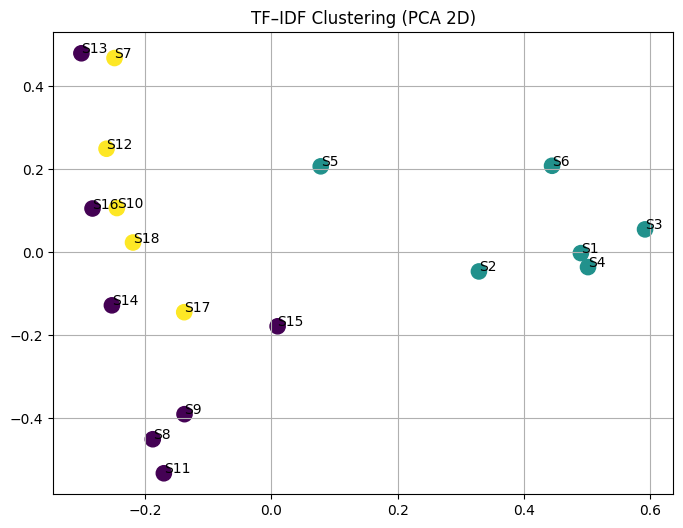

In [ ]:
# Create a new figure for the scatter plot
plt.figure(figsize=(8,6))  # Set figure size: width=8 inches, height=6 inches

# Scatter plot of the 2D PCA-transformed TF–IDF embeddings
plt.scatter(
    pts_tfidf[:,0],  # x-coordinates (first principal component)
    pts_tfidf[:,1],  # y-coordinates (second principal component)
    c=labels_tfidf,  # Color points according to their KMeans cluster labels
    s=120,           # Size of each point
    cmap='viridis'   # Color map used for different clusters
)

# Annotate each point with its sentence number
for i in range(len(sentences)):
    plt.annotate(
        f"S{i+1}",             # Label for the point (e.g., S1, S2,...)
        (pts_tfidf[i,0], pts_tfidf[i,1])  # Position of annotation
    )

# Add a title to the plot
plt.title("TF–IDF Clustering (PCA 2D)")

# Show grid lines for easier reading of the plot
plt.grid(True)

# Display the plot
plt.show()



# **Word2Vec (Word Embeddings)**

* A method to convert words into **dense numerical vectors** capturing semantic meaning.
* Words with **similar context** have **similar embeddings** in vector space.
* Uses **neural network architectures**:

  * **Skip-gram** – predicts surrounding words given a target word.
  * **CBOW (Continuous Bag-of-Words)** – predicts a target word from surrounding words.
* Embeddings are **low-dimensional** (e.g., 50–300 dimensions) and **dense** compared to one-hot vectors.
* Enables tasks like:

  * **Semantic similarity**
  * **Clustering of words or sentences**
  * **Text classification and search**




**Preprocessing for Word2Vec**

* Converts each sentence into a **list of words**.
* Lowercases all text and **removes punctuation, numbers, and special characters**.
* Splits text into **clean, meaningful tokens**.
* Ensures **consistent and noise-free input** for Word2Vec training.
* Preprocessed tokens allow the model to **learn accurate word embeddings**.



In [ ]:
# -------------------------------
# PREPROCESSING FOR WORD2VEC
# -------------------------------
tokenized = [simple_preprocess(sent) for sent in sentences]



**Training Word2Vec Model**

* Learns **dense vector representations** for words from the preprocessed text.
* Uses **Skip-gram** or **CBOW** architecture:

  * Skip-gram predicts surrounding words given a target word.
  * CBOW predicts the target word from surrounding words.
* **Vector size** determines the dimensionality of word embeddings.
* **Window size** defines how many neighboring words are considered.
* **Minimum word count** ignores rare words to reduce noise.
* **Multiple epochs** improve the quality of embeddings by iterating over data multiple times.




In [ ]:
# -------------------------------
# TRAIN WORD2VEC MODEL
# -------------------------------
w2v_model = Word2Vec(
    sentences=tokenized,
    vector_size=50,   # embedding dimension
    window=5,
    min_count=1,
    workers=4,
    sg=1,            # skip-gram
    epochs=200
)



**Building Sentence Embeddings**

* Combines **word embeddings** to create a single vector representation for a sentence.
* Computes the **average of all word vectors** in the sentence.
* Words not present in the model are **ignored** during averaging.
* Produces **dense, fixed-size vectors** for each sentence.
* Enables **semantic comparison** between sentences using distance or similarity measures.




In [ ]:
# -------------------------------
# BUILD SENTENCE EMBEDDINGS (Average word vectors)
# -------------------------------
def sentence_vector(tokens, model):
    vec = np.zeros(model.vector_size)
    count = 0
    for word in tokens:
        if word in model.wv:
            vec += model.wv[word]
            count += 1
    return vec / count if count > 0 else vec

emb_w2v = np.array([sentence_vector(tokens, w2v_model) for tokens in tokenized])

print("\n Word2Vec Sentence Embedding Matrix:\n", np.round(emb_w2v, 4))



 Word2Vec Sentence Embedding Matrix:
 [[-2.040e-02  2.960e-02 -7.480e-02 -1.770e-02 -8.410e-02 -1.059e-01
   1.402e-01  1.147e-01 -1.081e-01 -1.754e-01  4.830e-02 -2.415e-01
   1.213e-01  1.911e-01 -1.267e-01  3.580e-02  5.480e-02  1.447e-01
  -1.916e-01 -5.560e-02  1.981e-01  1.246e-01  2.831e-01  3.630e-02
   1.446e-01  8.690e-02  1.600e-02  1.993e-01 -1.520e-01  5.280e-02
  -1.213e-01 -9.640e-02  1.050e-02 -1.546e-01 -9.150e-02  4.140e-02
   2.114e-01  2.780e-02 -3.630e-02  4.690e-02  7.380e-02 -4.820e-02
  -1.000e-02 -3.220e-02  2.083e-01 -4.380e-02 -3.310e-02 -2.100e-01
   6.280e-02  1.056e-01]
 [-1.520e-02  2.540e-02 -7.570e-02 -2.480e-02 -8.250e-02 -1.086e-01
   1.378e-01  1.240e-01 -1.040e-01 -1.740e-01  5.960e-02 -2.428e-01
   1.150e-01  1.920e-01 -1.154e-01  4.640e-02  6.360e-02  1.405e-01
  -1.995e-01 -4.950e-02  1.799e-01  1.132e-01  2.817e-01  2.760e-02
   1.328e-01  8.380e-02  2.720e-02  1.987e-01 -1.367e-01  4.780e-02
  -1.147e-01 -1.026e-01  3.100e-03 -1.597e-01 -8.360

**Distance and Similarity Matrices**

* Computes **Euclidean distances** between all pairs of sentence embeddings.

  * Measures how far apart sentences are in the embedding space.
  * Sum of Squared Distances (SSD) quantifies the overall spread of embeddings.
* Computes **Cosine similarity** between sentence embeddings.

  * Measures the **angle-based similarity**, ignoring magnitude.
  * High cosine similarity → sentences are **semantically close**.
* These matrices are essential for **clustering, retrieval, and similarity analysis**.




In [ ]:
# -------------------------------
# DISTANCE MATRIX + SSD
# -------------------------------
D_w2v = euclidean_distances(emb_w2v)
print("\n Euclidean Distance Matrix (Word2Vec):\n", np.round(D_w2v, 4))

SSD_w2v = np.sum(D_w2v**2)
print("\n Sum of Squared Distances (SSD Word2Vec):", SSD_w2v)



# -------------------------------
# COSINE SIMILARITY MATRIX
# -------------------------------
cos_w2v = cosine_similarity(emb_w2v)
print("\n Cosine Similarity Matrix (Word2Vec):\n", np.round(cos_w2v, 4))



 Euclidean Distance Matrix (Word2Vec):
 [[0.     0.0554 0.165  0.2293 0.1059 0.1492 0.1012 0.1431 0.1333 0.1002
  0.1319 0.1213 0.0996 0.0982 0.0846 0.1143 0.1256 0.0863]
 [0.0554 0.     0.1859 0.2515 0.118  0.1673 0.0798 0.1284 0.1176 0.0928
  0.1097 0.11   0.0861 0.1114 0.0816 0.1162 0.1414 0.0978]
 [0.165  0.1859 0.     0.0793 0.1049 0.0417 0.2248 0.2947 0.2832 0.2062
  0.2728 0.2275 0.1993 0.1396 0.1761 0.1548 0.1324 0.1468]
 [0.2293 0.2515 0.0793 0.     0.1601 0.0962 0.2875 0.3587 0.3479 0.2679
  0.3391 0.285  0.2588 0.1973 0.2386 0.2104 0.1797 0.2044]
 [0.1059 0.118  0.1049 0.1601 0.     0.0844 0.1456 0.2234 0.2119 0.1417
  0.2017 0.1562 0.1256 0.089  0.1196 0.1062 0.0827 0.0826]
 [0.1492 0.1673 0.0417 0.0962 0.0844 0.     0.2024 0.2771 0.2652 0.1892
  0.2554 0.2079 0.1772 0.1199 0.1561 0.134  0.119  0.1279]
 [0.1012 0.0798 0.2248 0.2875 0.1456 0.2024 0.     0.1066 0.0968 0.074
  0.0854 0.0674 0.0539 0.1216 0.0975 0.1176 0.1497 0.106 ]
 [0.1431 0.1284 0.2947 0.3587 0.2234 0.2771


**KMeans Clustering**

* Groups sentences into **clusters based on similarity** in the embedding space.
* Number of clusters is **predefined** (e.g., 3 clusters).
* Algorithm iteratively assigns sentences to the **nearest cluster centroid**.
* Centroids are **updated** until convergence (minimizing within-cluster distances).
* Cluster labels indicate **which sentences belong to each group**, helping identify semantic similarity patterns.




In [ ]:

# -------------------------------
# KMEANS CLUSTERING
# -------------------------------
km_w2v = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_w2v = km_w2v.fit_predict(emb_w2v)
print("\n Cluster Labels (Word2Vec):", labels_w2v)



 Cluster Labels (Word2Vec): [1 1 0 0 1 0 1 2 2 1 2 1 1 1 1 1 1 1]



**PCA for Visualization**

* Reduces **high-dimensional sentence embeddings** to **2D or 3D** for plotting.
* Preserves **maximum variance** in the data using principal components.
* Enables **visual inspection** of clusters and relationships between sentences.


**Plotting Sentence Clusters**

* Scatter plot represents sentences in **reduced 2D space**.
* Points are **colored by cluster assignment**.
* Annotations label sentences for **easy identification**.
* Visualization helps to **interpret clustering results** and understand semantic groupings.




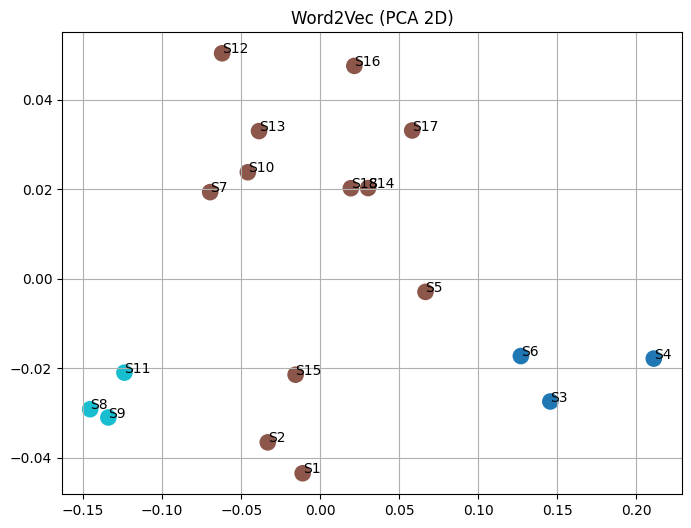

In [ ]:

# -------------------------------
# PCA FOR VISUALIZATION
# -------------------------------
pts_w2v = PCA(n_components=2).fit_transform(emb_w2v)

# -------------------------------
# PLOT
# -------------------------------

plt.figure(figsize=(8,6))
plt.scatter(pts_w2v[:,0], pts_w2v[:,1], c=labels_w2v, s=120, cmap='tab10')  # 'tab10' is bright, avoids grey

for i in range(len(sentences)):
    plt.annotate(f"S{i+1}", (pts_w2v[i,0], pts_w2v[i,1]))

plt.title("Word2Vec (PCA 2D)")
plt.grid(True)
plt.show()


# BERT EMBEDDINGS

**Generate BERT Embeddings**

1. **Semantic Representation**: Converts sentences into vectors that capture their meaning and context.
2. **High-Dimensional Vectors**: Each sentence is represented by a dense vector of 384 features.
3. **Context Awareness**: Embeddings consider word order and relationships, unlike simple word counts.
4. **Numerical Conversion**: Transforms text into a format suitable for machine learning tasks like clustering or similarity analysis.
5. **Consistent and Pretrained**: Uses a pre-trained model to generate embeddings without needing to train from scratch.


In [ ]:

# Load the pre-trained SentenceTransformer model "all-MiniLM-L6-v2"
# - This model generates sentence embeddings capturing semantic meaning
bert = SentenceTransformer("all-MiniLM-L6-v2")

# Encode the list of sentences into dense vector representations
# - Each sentence is mapped to a high-dimensional vector (384-dimensional for this model)
# - These embeddings capture contextual and semantic information, unlike simple bag-of-words
emb_bert = bert.encode(sentences)

# Print the embedding matrix rounded to 4 decimal places
# - Each row corresponds to a sentence
# - Each column corresponds to a feature of the embedding
print("\n BERT Embedding Matrix:\n", np.round(emb_bert, 4))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


 BERT Embedding Matrix:
 [[ 0.039   0.0262 -0.0402 ...  0.029   0.0464  0.055 ]
 [ 0.109  -0.0008  0.0577 ...  0.0326 -0.0247  0.0504]
 [ 0.075   0.0046  0.0268 ...  0.0325  0.0139  0.0734]
 ...
 [ 0.0495  0.0804  0.045  ...  0.0389 -0.0817 -0.0741]
 [-0.034   0.0506 -0.0153 ...  0.0615  0.0191 -0.0485]
 [-0.0349 -0.0048 -0.0069 ...  0.009   0.0037 -0.062 ]]


**Compute Distances and Similarities**

**Distance and Similarity Analysis of BERT Embeddings**

1. **Euclidean Distance**: Measures straight-line distance between sentence embeddings; smaller distance → sentences are more similar.
2. **Pairwise Matrix**: Computes distances between all sentence pairs, forming a square matrix for analysis.
3. **Sum of Squared Distances (SSD)**: Aggregates all pairwise distances into a single value representing overall spread of sentences in embedding space.
4. **Cosine Similarity**: Measures the angle between embedding vectors; higher value indicates stronger semantic similarity.
5. **Semantic Comparison**: Both Euclidean and cosine metrics help quantify how sentences relate to each other based on meaning captured by embeddings.


In [ ]:
# -------------------------------
# Compute pairwise distances and similarities for BERT embeddings
# -------------------------------

# Euclidean distances
# - Measures the straight-line distance between sentence embeddings in high-dimensional space
# - Smaller distances indicate more similar sentences (in terms of embedding features)
D_bert = euclidean_distances(emb_bert)
print("\n Euclidean Distance Matrix (BERT):\n", np.round(D_bert, 4))

# Sum of Squared Distances (SSD)
# - Sum of squares of all pairwise Euclidean distances
# - Can be used as a measure of overall spread or compactness of the embedding space
SSD_bert = np.sum(D_bert**2)
print("\n Sum of Squared Distances (SSD BERT):", SSD_bert)

# Cosine similarity
# - Measures the cosine of the angle between two vectors (embedding vectors)
# - Values close to 1 indicate high semantic similarity; values close to 0 indicate dissimilarity
cos_bert = cosine_similarity(emb_bert)
print("\n Cosine Similarity Matrix (BERT):\n", np.round(cos_bert, 4))



 Euclidean Distance Matrix (BERT):
 [[0.     1.2394 1.3396 1.2602 1.3002 1.344  1.333  1.3867 1.4002 1.3684
  1.4157 1.3152 1.3847 1.4021 1.3912 1.3523 1.3622 1.4486]
 [1.2394 0.     1.2462 1.1152 1.3245 1.281  1.4058 1.3734 1.3867 1.4265
  1.4298 1.4023 1.3494 1.4052 1.3856 1.3225 1.4255 1.4282]
 [1.3396 1.2462 0.     1.2467 1.1967 1.2626 1.426  1.3812 1.3807 1.4136
  1.422  1.3576 1.3386 1.3117 1.38   1.3727 1.4242 1.3461]
 [1.2602 1.1152 1.2467 0.     1.1821 1.3388 1.4096 1.4282 1.44   1.4605
  1.451  1.3985 1.2886 1.3844 1.4158 1.3809 1.4323 1.4405]
 [1.3002 1.3245 1.1967 1.1821 0.     1.248  1.3983 1.3666 1.4077 1.4142
  1.4496 1.4201 1.3303 1.3636 1.3788 1.4437 1.3965 1.4329]
 [1.344  1.281  1.2626 1.3388 1.248  0.     1.4046 1.4444 1.429  1.4621
  1.4347 1.4504 1.4488 1.445  1.4913 1.4766 1.4289 1.4242]
 [1.333  1.4058 1.426  1.4096 1.3983 1.4046 0.     1.1644 1.2043 1.1602
  1.2703 1.1529 1.2498 1.2898 1.2554 1.322  1.3134 1.1568]
 [1.3867 1.3734 1.3812 1.4282 1.3666 1.4444 1.

**KMeans Clustering of BERT Embeddings**

1. **Clustering Goal**: Group sentences into 3 clusters based on semantic similarity of BERT embeddings.

2. **KMeans Initialization**: Runs multiple times with different seeds to find the most stable clustering solution.

3. **Reproducibility**: Setting a random state ensures the clustering results are consistent across runs.

4. **Assignment**: Each sentence is assigned a cluster label indicating its group membership.

5. **Interpretation**: Cluster labels help identify sentences with similar meanings according to BERT embeddings.


In [ ]:
# -------------------------------
# KMeans clustering on BERT embeddings
# -------------------------------

# KMeans initialization
# - n_clusters=3: We are grouping the sentences into 3 clusters
# - n_init=10: KMeans will run 10 times with different centroid seeds to choose the best result
# - random_state=42: Ensures reproducibility of the clustering results

km_bert = KMeans(n_clusters=3, n_init=10, random_state=42)

# Fit KMeans on BERT embeddings and predict cluster labels
# - Each sentence is assigned a cluster index (0, 1, or 2)
labels_bert = km_bert.fit_predict(emb_bert)

# Print cluster assignments
# - Labels indicate which cluster each sentence belongs to
print("\n Cluster Labels (BERT):", labels_bert)



 Cluster Labels (BERT): [2 2 2 2 2 2 1 1 1 1 1 1 0 0 0 0 0 0]


**PCA for 2D Visualization**

1. Applies PCA to the sentence embeddings generated by the BERT model.

2. Reduces the original high-dimensional embeddings to two dimensions for easier visualization.

3. Computes the principal components that capture the most variance in the embeddings.
4. Projects each sentence’s embedding onto these two principal axes.

5. Produces 2D coordinates that can be used to plot and visually inspect sentence clusters.


In [ ]:
# -------------------------------
# PCA for 2D visualization of BERT embeddings
# -------------------------------

# PCA (Principal Component Analysis) reduces high-dimensional embeddings to 2D
# - n_components=2: Reduce BERT embeddings to 2 dimensions for easy plotting
# - fit_transform(): PCA computes the principal components and projects the embeddings onto them

pts_bert = PCA(n_components=2).fit_transform(emb_bert)


**Plot Clusters**

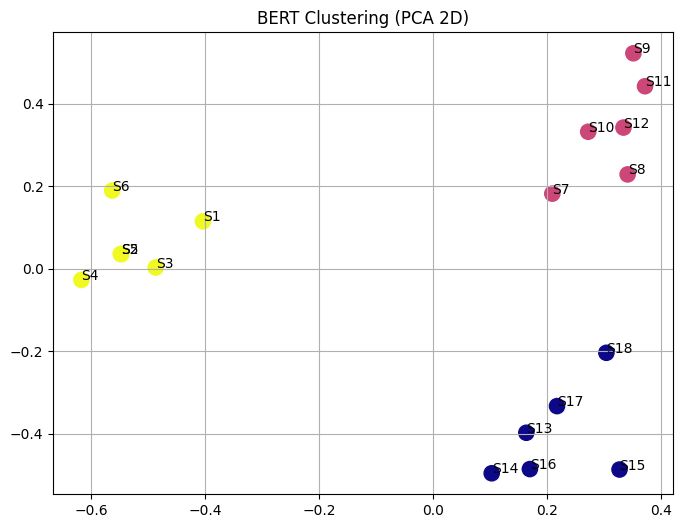

In [ ]:
# -------------------------------
# Plotting BERT clusters in 2D
# -------------------------------

# Create a figure with size 8x6 inches
plt.figure(figsize=(8,6))

# Scatter plot of the 2D PCA points
# - pts_bert[:,0] -> x-coordinates (first principal component)
# - pts_bert[:,1] -> y-coordinates (second principal component)
# - c=labels_bert -> colors points according to their cluster labels
# - s=120 -> size of each point
# - cmap='plasma' -> colormap for clusters
plt.scatter(pts_bert[:,0], pts_bert[:,1], c=labels_bert, s=120, cmap='plasma')

# Annotate each point with its sentence number (S1, S2, ...)
for i in range(len(sentences)):
    plt.annotate(f"S{i+1}", (pts_bert[i,0], pts_bert[i,1]))

# Add a title
plt.title("BERT Clustering (PCA 2D)")

# Add a grid for better readability
plt.grid(True)

# Display the plot
plt.show()
